In [15]:
import seaborn as sns

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

import pyswarms as ps
from deap import base, creator, tools, algorithms

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [2]:
df = pd.read_csv('cleandata.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

data = df[['demand_kWh']].values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

train_size = int(len(data_scaled) * 0.8)
train = data_scaled[:train_size]
test = data_scaled[train_size:]

In [3]:
#SARIMA Model
sarima = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,24))
sarima_fit = sarima.fit(method='powell', maxiter=200, disp=False, 
                        low_memory=True, conserve_memory=True)

sarima_pred = sarima_fit.forecast(steps=len(test))
residuals = test.flatten() - sarima_pred.flatten()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method powell is: xtol, ftol, maxfun, start_direc. The list of unsupported keyword arguments passed include: conserve_memory. After release 0.14, this will raise.
  warnings.warn(


In [4]:
#create sequences for TCN
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X_res, y_res = create_sequences(residuals, window)
X_res = X_res.reshape((X_res.shape[0], X_res.shape[1], 1))

In [5]:
def build_tcn(filters, kernel, lr):
    model = Sequential()
    model.add(Conv1D(filters=int(filters), kernel_size=int(kernel), activation='relu', input_shape=(window,1)))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

def fitness_eval(filters, kernel, lr):
    tf.keras.backend.clear_session()
    model = build_tcn(filters, kernel, lr)
    model.fit(X_res, y_res, epochs=3, batch_size=32, verbose=0, shuffle=False)
    pred = model.predict(X_res, verbose=0)
    return mean_squared_error(y_res, pred)


In [6]:
#PSO Hyperparameter Optimization
best_pos_pso = np.array([67.1641206, 4.81074316, 0.00183906319])
best_cost_pso = None

print("PSO Best Hyperparameters:", best_pos_pso)
tf.keras.backend.clear_session()
pso_model = build_tcn(best_pos_pso[0], best_pos_pso[1], best_pos_pso[2])
pso_model.fit(X_res, y_res, epochs=10, batch_size=32, verbose=0, shuffle=False)


PSO Best Hyperparameters: [6.71641206e+01 4.81074316e+00 1.83906319e-03]



2026-04-26 12:16:26,753 - tensorflow - WARNING - From C:\Users\ASUS TUF-Pc\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

C:\Users\ASUS TUF-Pc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#GA Hyperparameter Optimization
best_ind = [40.0, 4.0, 0.005730273212405962]

print("GA Best Hyperparameters:", best_ind)
tf.keras.backend.clear_session()
ga_model = build_tcn(best_ind[0], best_ind[1], best_ind[2])
ga_model.fit(X_res, y_res, epochs=10, batch_size=32, verbose=0, shuffle=False)


GA Best Hyperparameters: [40.0, 4.0, 0.005730273212405962]


In [8]:
#final forecasts
res_pso = pso_model.predict(X_res).flatten()
res_ga = ga_model.predict(X_res).flatten()

final_pso = sarima_pred[window:].flatten() + res_pso
final_ga = sarima_pred[window:].flatten() + res_ga
actual = test.flatten()[window:]

324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [9]:
#eval metrics
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)))

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} RESULTS")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"SMAPE: {smape_val:.2f}%")
    print(f"R2: {r2:.4f}")
    return mae, rmse, smape_val, r2

metrics_pso = evaluate("SARIMA-PSO-TCN", actual, final_pso)
metrics_ga = evaluate("SARIMA-GA-TCN", actual, final_ga)


SARIMA-PSO-TCN RESULTS
MAE: 0.0498
RMSE: 0.0675
SMAPE: 49.17%
R2: 0.8307

SARIMA-GA-TCN RESULTS
MAE: 0.0579
RMSE: 0.0772
SMAPE: 62.75%
R2: 0.7789


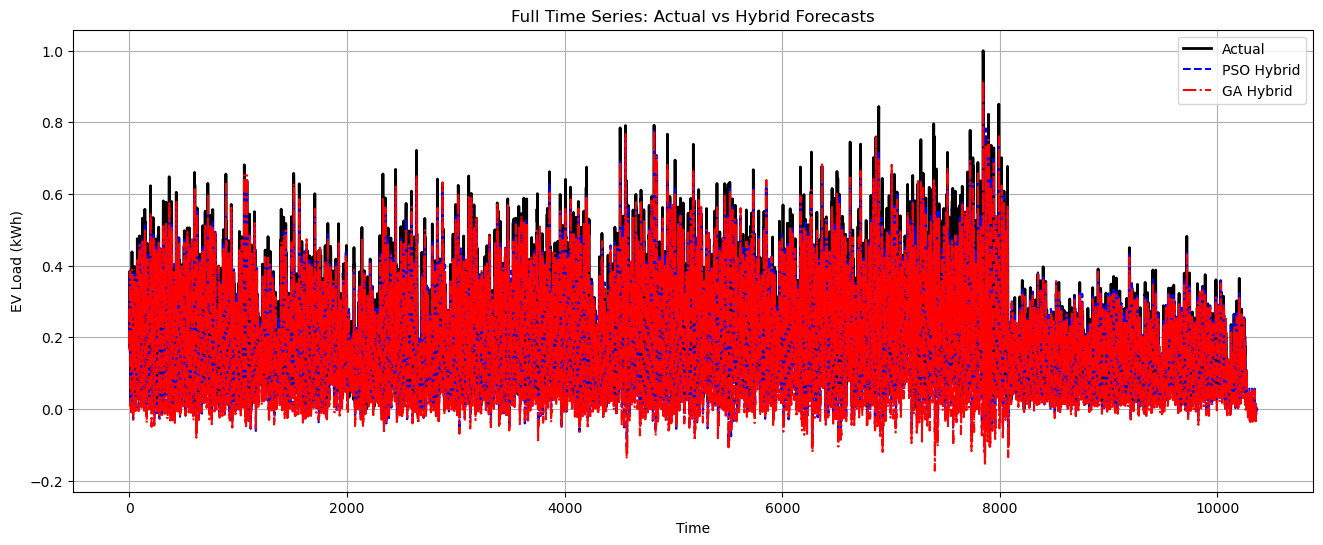

In [10]:
plt.figure(figsize=(16,6))
plt.plot(actual, label='Actual', color='black', linewidth=2)
plt.plot(final_pso, label='PSO Hybrid', color='blue', linestyle='--')
plt.plot(final_ga, label='GA Hybrid', color='red', linestyle='-.')
plt.title("Full Time Series: Actual vs Hybrid Forecasts")
plt.xlabel("Time")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

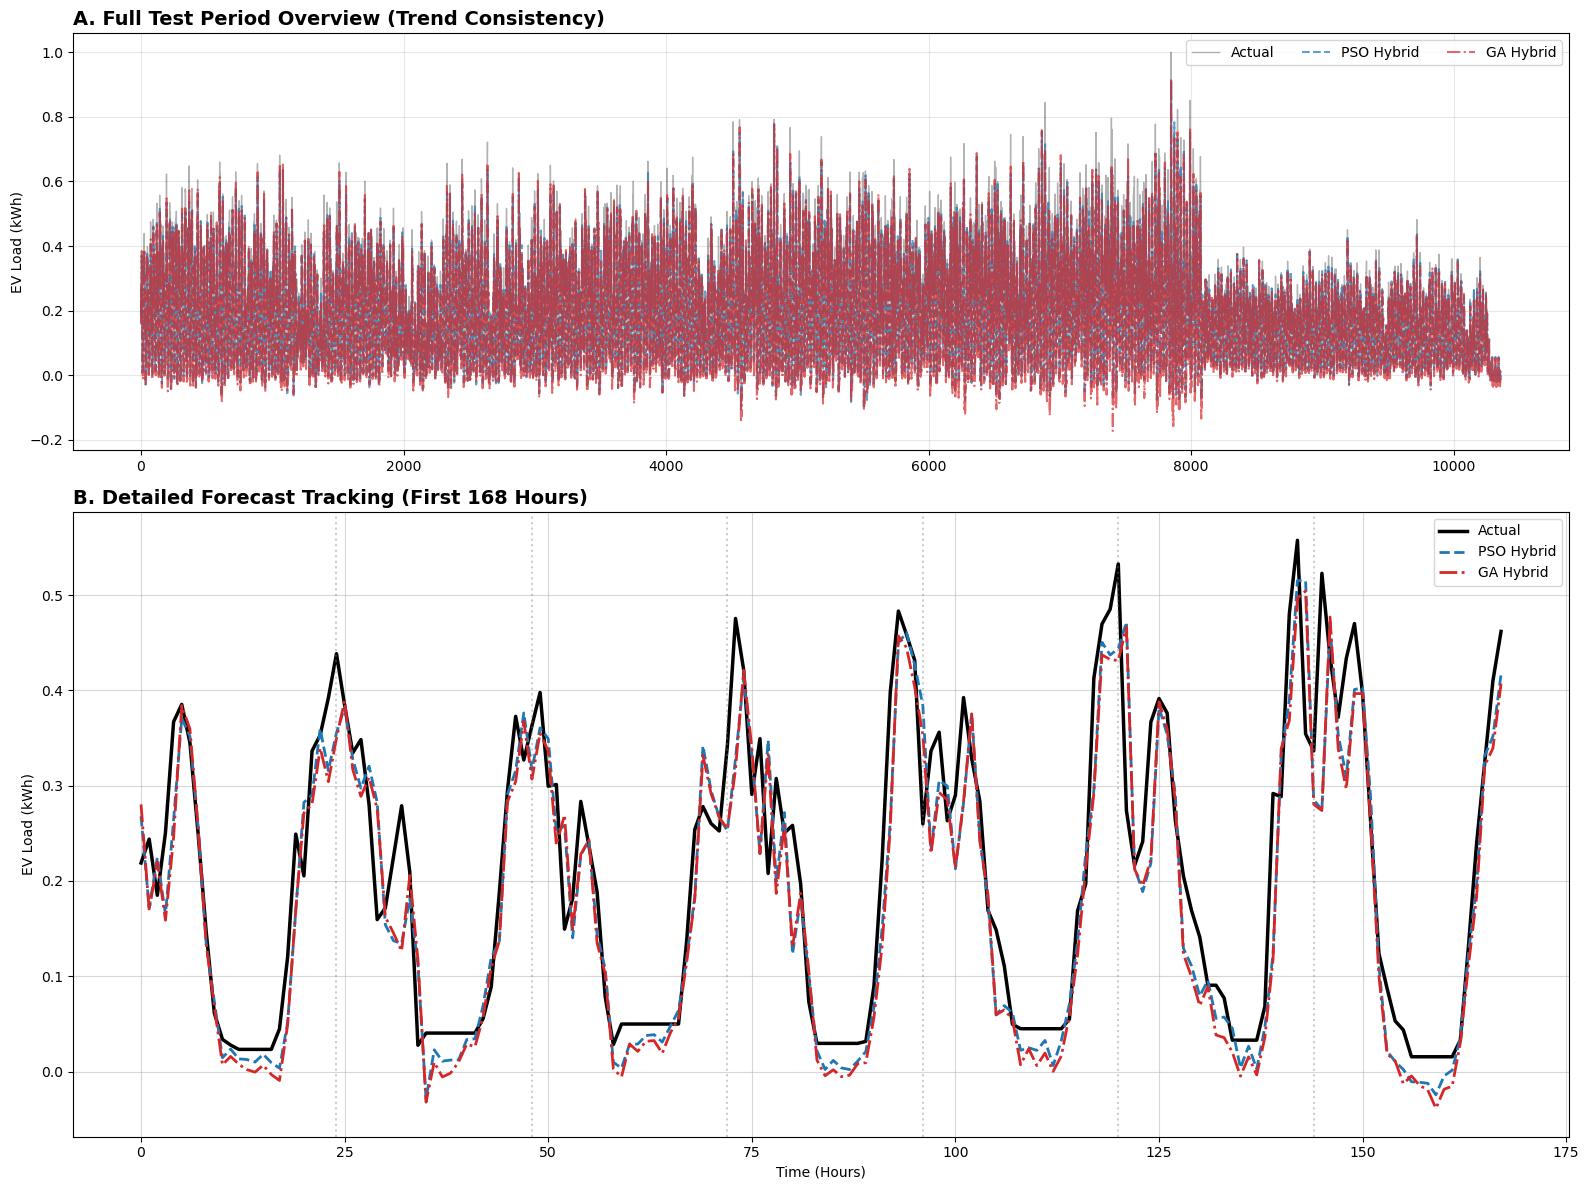

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1.5]})

ax1.plot(actual, label='Actual', color='black', alpha=0.3, linewidth=1)
ax1.plot(final_pso, label='PSO Hybrid', color='#1f77b4', alpha=0.7, linestyle='--')
ax1.plot(final_ga, label='GA Hybrid', color='#d62728', alpha=0.7, linestyle='-.')
ax1.set_title("A. Full Test Period Overview (Trend Consistency)", loc='left', fontsize=14, fontweight='bold')
ax1.set_ylabel("EV Load (kWh)")
ax1.legend(loc='upper right', ncol=3)
ax1.grid(True, alpha=0.3)

zoom_range = 168  #One week of hourly data
ax2.plot(actual[:zoom_range], label='Actual', color='black', linewidth=2.5)
ax2.plot(final_pso[:zoom_range], label='PSO Hybrid', color='#1f77b4', linewidth=2, linestyle='--')
ax2.plot(final_ga[:zoom_range], label='GA Hybrid', color='#d62728', linewidth=2, linestyle='-.')

ax2.set_title(f"B. Detailed Forecast Tracking (First {zoom_range} Hours)", loc='left', fontsize=14, fontweight='bold')
ax2.set_xlabel("Time (Hours)")
ax2.set_ylabel("EV Load (kWh)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax2.axvline(x=i, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

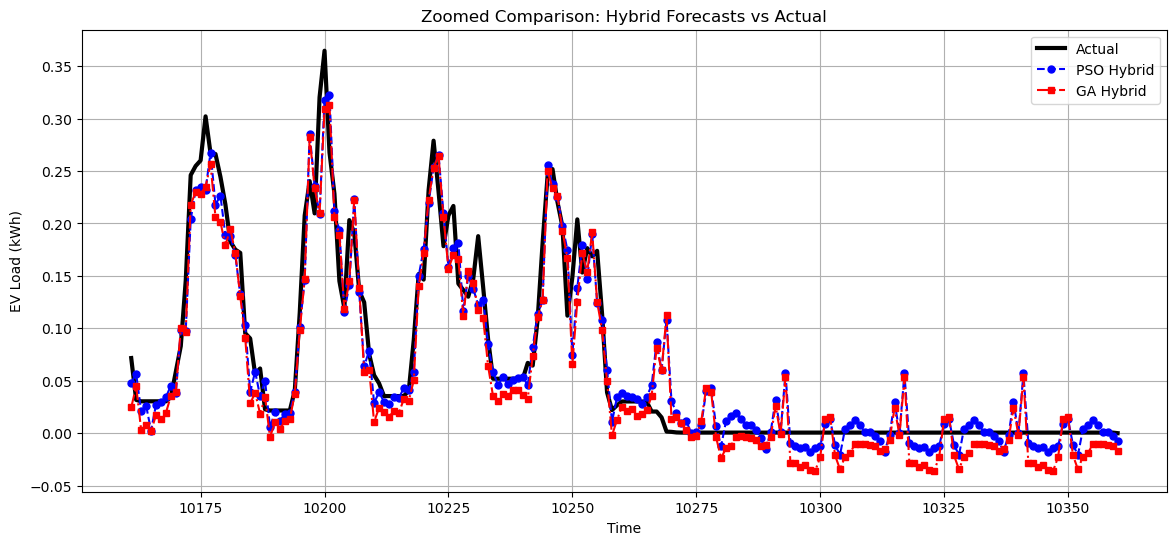

In [12]:
#zoomed forecast comparison
zoom_points = 200
x_zoom = range(len(actual)-zoom_points, len(actual))

plt.figure(figsize=(14,6))
plt.plot(x_zoom, actual[-zoom_points:], label='Actual', color='black', linewidth=3)
plt.plot(x_zoom, final_pso[-zoom_points:], label='PSO Hybrid', color='blue', linestyle='--', marker='o', markersize=5)
plt.plot(x_zoom, final_ga[-zoom_points:], label='GA Hybrid', color='red', linestyle='-.', marker='s', markersize=5)
plt.title("Zoomed Comparison: Hybrid Forecasts vs Actual")
plt.xlabel("Time")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

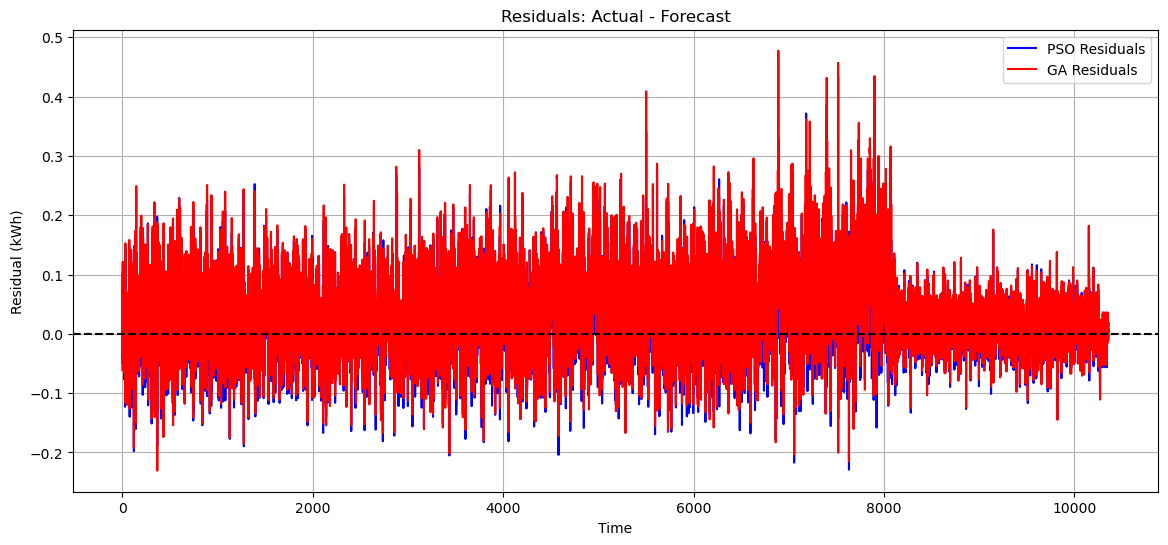

In [13]:
#residuals
residual_pso = actual - final_pso
residual_ga = actual - final_ga

plt.figure(figsize=(14,6))
plt.plot(residual_pso, label='PSO Residuals', color='blue')
plt.plot(residual_ga, label='GA Residuals', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals: Actual - Forecast")
plt.xlabel("Time")
plt.ylabel("Residual (kWh)")
plt.legend()
plt.grid(True)
plt.show()

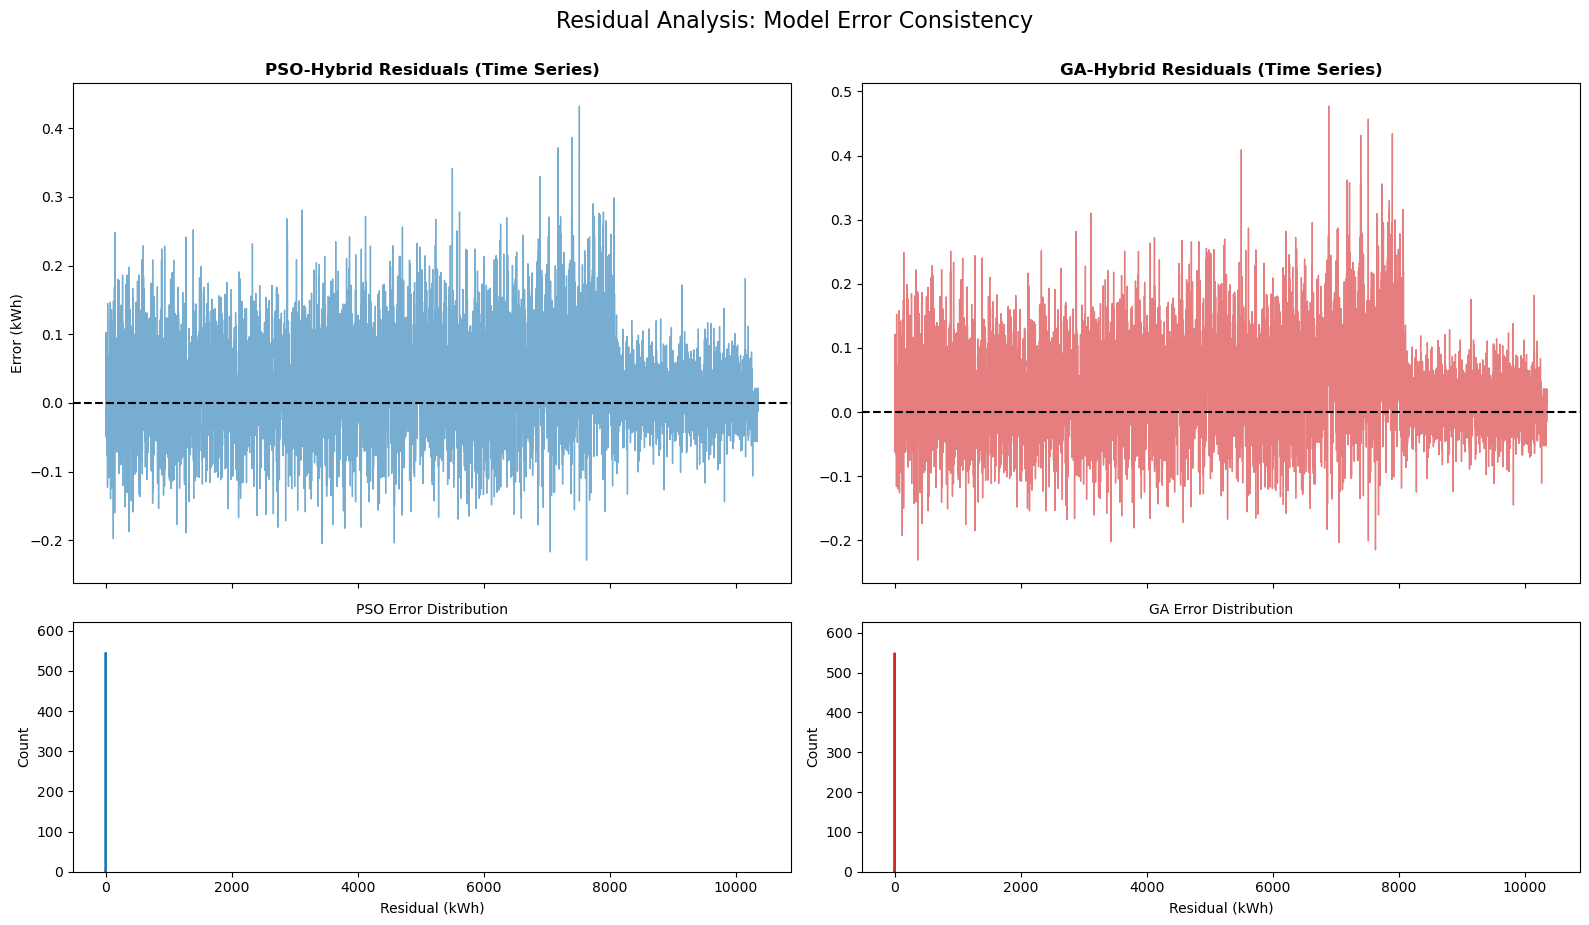

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex='col', gridspec_kw={'height_ratios': [2, 1]})

# --- PSO RESIDUALS (Left Column) ---
# Line Plot
axes[0, 0].plot(residual_pso, color='#1f77b4', alpha=0.6, linewidth=1)
axes[0, 0].set_title('PSO-Hybrid Residuals (Time Series)', fontsize=12, fontweight='bold')
axes[0, 0].axhline(0, color='black', lw=1.5, ls='--')
axes[0, 0].set_ylabel('Error (kWh)')

# Histogram / KDE
sns.histplot(residual_pso, kde=True, ax=axes[1, 0], color='#1f77b4')
axes[1, 0].set_title('PSO Error Distribution', fontsize=10)
axes[1, 0].set_xlabel('Residual (kWh)')

# --- GA RESIDUALS (Right Column) ---
# Line Plot
axes[0, 1].plot(residual_ga, color='#d62728', alpha=0.6, linewidth=1)
axes[0, 1].set_title('GA-Hybrid Residuals (Time Series)', fontsize=12, fontweight='bold')
axes[0, 1].axhline(0, color='black', lw=1.5, ls='--')

# Histogram / KDE
sns.histplot(residual_ga, kde=True, ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('GA Error Distribution', fontsize=10)
axes[1, 1].set_xlabel('Residual (kWh)')

# Final formatting
plt.suptitle("Residual Analysis: Model Error Consistency", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

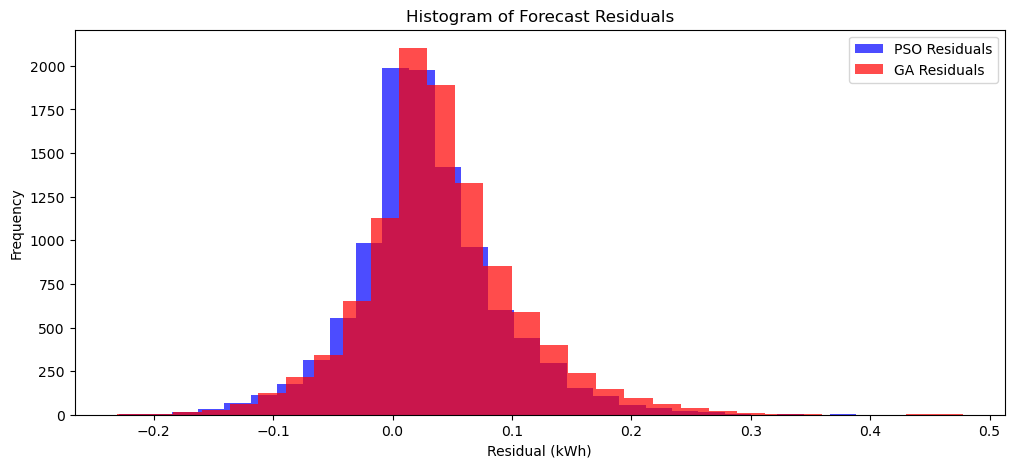

In [17]:
#histogram of residuals
plt.figure(figsize=(12,5))
plt.hist(residual_pso, bins=30, alpha=0.7, label='PSO Residuals', color='blue')
plt.hist(residual_ga, bins=30, alpha=0.7, label='GA Residuals', color='red')
plt.title("Histogram of Forecast Residuals")
plt.xlabel("Residual (kWh)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

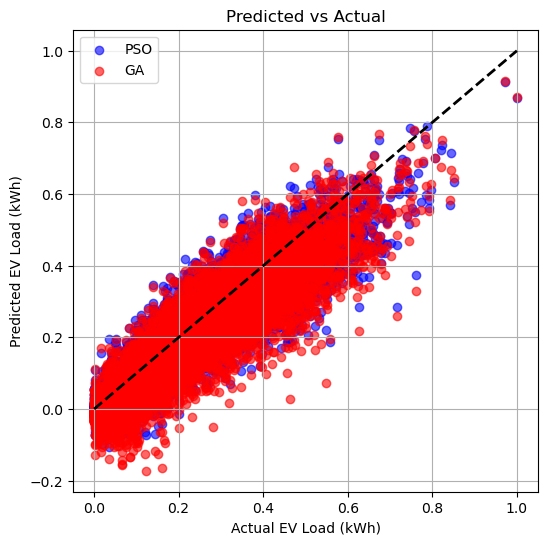

In [18]:
#scatter Plot: predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(actual, final_pso, label='PSO', color='blue', alpha=0.6)
plt.scatter(actual, final_ga, label='GA', color='red', alpha=0.6)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'k--', lw=2)
plt.xlabel("Actual EV Load (kWh)")
plt.ylabel("Predicted EV Load (kWh)")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

            Model       MAE      RMSE      SMAPE        R2
0  SARIMA-PSO-TCN  0.049752  0.067532  49.165168  0.830713
1   SARIMA-GA-TCN  0.057897  0.077177  62.752158  0.778907


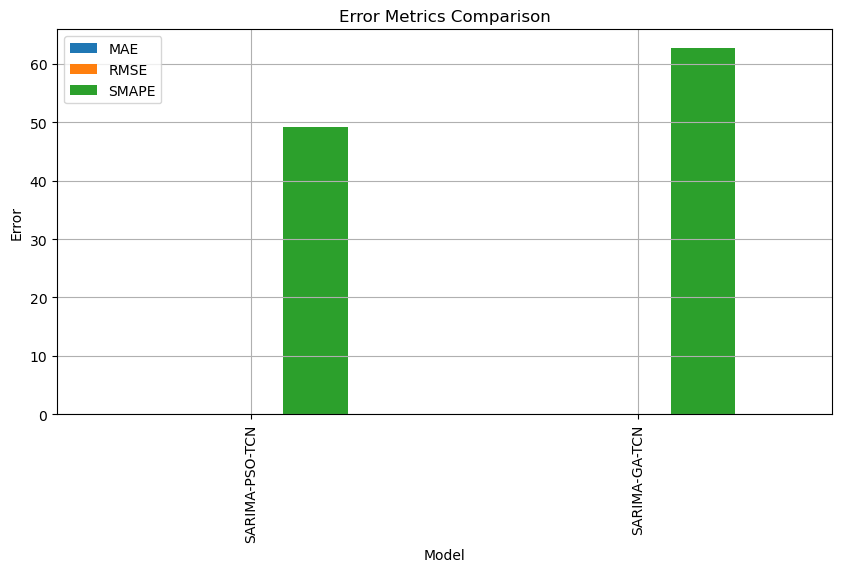

In [19]:
#metrics cmparison
metrics_df = pd.DataFrame({
    'Model': ['SARIMA-PSO-TCN', 'SARIMA-GA-TCN'],
    'MAE': [metrics_pso[0], metrics_ga[0]],
    'RMSE': [metrics_pso[1], metrics_ga[1]],
    'SMAPE': [metrics_pso[2], metrics_ga[2]],
    'R2': [metrics_pso[3], metrics_ga[3]]
})
print(metrics_df)

metrics_df.set_index('Model')[['MAE','RMSE','SMAPE']].plot(kind='bar', figsize=(10,5))
plt.title("Error Metrics Comparison")
plt.ylabel("Error")
plt.grid(True)
plt.show()


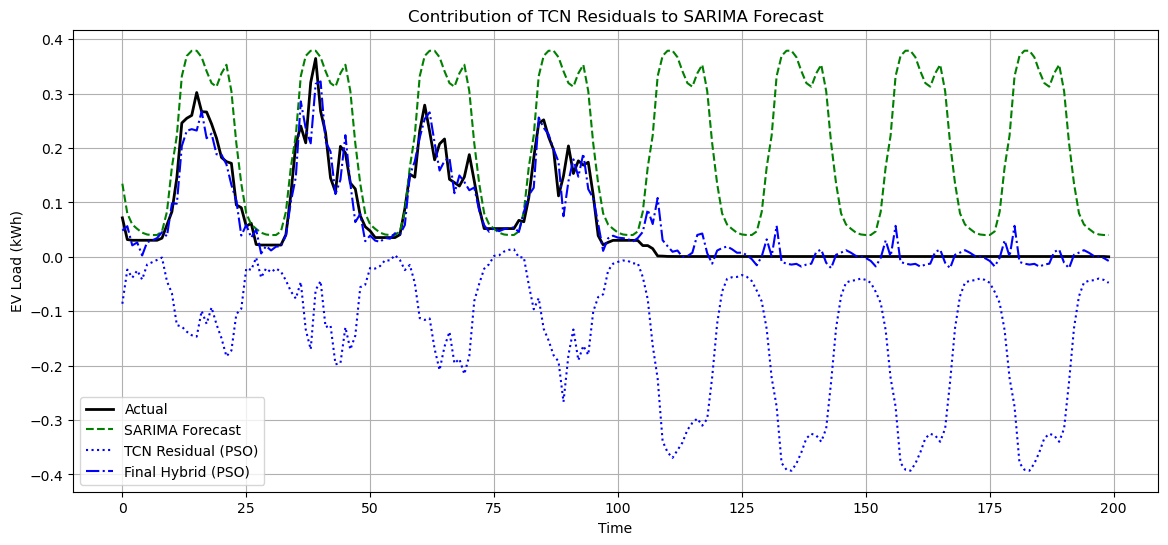

In [20]:
#TCN contribution to SARIMA forecast
plt.figure(figsize=(14,6))
plt.plot(actual[-zoom_points:], label='Actual', color='black', linewidth=2)
plt.plot(sarima_pred[window:][-zoom_points:], label='SARIMA Forecast', color='green', linestyle='--')
plt.plot(res_pso[-zoom_points:], label='TCN Residual (PSO)', color='blue', linestyle=':')
plt.plot(final_pso[-zoom_points:], label='Final Hybrid (PSO)', color='blue', linestyle='-.')
plt.title("Contribution of TCN Residuals to SARIMA Forecast")
plt.xlabel("Time")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
#save functions
output_dir = Path("evNew2_fixed_outputs")
output_dir.mkdir(exist_ok=True)

hybrid_timestamps = df['timestamp'].iloc[train_size + window:].reset_index(drop=True)

actual_kwh = scaler.inverse_transform(actual.reshape(-1, 1)).flatten()
final_pso_kwh = scaler.inverse_transform(final_pso.reshape(-1, 1)).flatten()
final_ga_kwh = scaler.inverse_transform(final_ga.reshape(-1, 1)).flatten()

hybrid_export = pd.DataFrame({
    'timestamp': hybrid_timestamps,
    'actual_scaled': actual,
    'sarima_pso_tcn_scaled': final_pso,
    'sarima_ga_tcn_scaled': final_ga,
    'actual_kwh': actual_kwh,
    'sarima_pso_tcn_kwh': final_pso_kwh,
    'sarima_ga_tcn_kwh': final_ga_kwh
})

hybrid_export.to_csv(output_dir / 'hybrid_forecasts_export.csv', index=False)

metrics_scaled_df = pd.DataFrame({
    'Model': ['SARIMA-PSO-TCN', 'SARIMA-GA-TCN'],
    'MAE': [metrics_pso[0], metrics_ga[0]],
    'RMSE': [metrics_pso[1], metrics_ga[1]],
    'SMAPE (%)': [metrics_pso[2], metrics_ga[2]],
    'R2': [metrics_pso[3], metrics_ga[3]]
})
metrics_scaled_df.to_csv(output_dir / 'hybrid_metrics_scaled.csv', index=False)

def evaluate_kwh(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, smape_val, r2

metrics_pso_kwh = evaluate_kwh(actual_kwh, final_pso_kwh)
metrics_ga_kwh = evaluate_kwh(actual_kwh, final_ga_kwh)

metrics_kwh_df = pd.DataFrame({
    'Model': ['SARIMA-PSO-TCN', 'SARIMA-GA-TCN'],
    'MAE': [metrics_pso_kwh[0], metrics_ga_kwh[0]],
    'RMSE': [metrics_pso_kwh[1], metrics_ga_kwh[1]],
    'SMAPE (%)': [metrics_pso_kwh[2], metrics_ga_kwh[2]],
    'R2': [metrics_pso_kwh[3], metrics_ga_kwh[3]]
})
metrics_kwh_df.to_csv(output_dir / 'hybrid_metrics_kwh.csv', index=False)

fixed_hyperparameters = {
    'sarima_pso_tcn': {
        'filters': int(round(best_pos_pso[0])),
        'kernel_size': int(round(best_pos_pso[1])),
        'learning_rate': float(best_pos_pso[2])
    },
    'sarima_ga_tcn': {
        'filters': int(round(best_ind[0])),
        'kernel_size': int(round(best_ind[1])),
        'learning_rate': float(best_ind[2])
    }
}

with open(output_dir / 'fixed_hyperparameters.json', 'w') as f:
    json.dump(fixed_hyperparameters, f, indent=2)

pso_model.save(output_dir / 'sarima_pso_tcn_model.keras')
ga_model.save(output_dir / 'sarima_ga_tcn_model.keras')

print("Saved exports to:", output_dir.resolve())
print(hybrid_export.head())


Saved exports to: C:\Users\ASUS TUF-Pc\Desktop\Jupyter Notebook\JERWIN\EV_CHARGING_LOAD-main (test)\evNew2_fixed_outputs
            timestamp  actual_scaled  sarima_pso_tcn_scaled  \
0 2022-09-29 12:00:00       0.218874               0.268008   
1 2022-09-29 13:00:00       0.243969               0.171751   
2 2022-09-29 14:00:00       0.184980               0.224701   
3 2022-09-29 15:00:00       0.250599               0.164859   
4 2022-09-29 16:00:00       0.367094               0.264268   

   sarima_ga_tcn_scaled  actual_kwh  sarima_pso_tcn_kwh  sarima_ga_tcn_kwh  
0              0.280378   49.210976           60.257987          63.039201  
1              0.169277   54.853132           38.615941          38.059630  
2              0.220151   41.590216           50.521040          49.498061  
3              0.158822   56.343823           37.066255          35.708941  
4              0.245673   82.536137           59.417115          55.236280  
